# Heart Disease Prediction using Support Vector Machine
## Complete ML Pipeline with Data Analysis and Model Evaluation

This notebook implements a comprehensive Machine Learning model to predict cardiovascular disease using Support Vector Machine (SVM).

## Step 0: Import Required Libraries

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1: Data Understanding
Load and explore the dataset to understand its structure

In [2]:
# Load the CSV file
df = pd.read_csv('Cardiovascular_Disease_Dataset.csv')

# Display dataset shape
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Dataset Shape: {df.shape}")
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

# Display column names and data types
print("\nColumn Names and Data Types:")
print(df.dtypes)

# Display first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())
print(f"Total Missing Values: {df.isnull().sum().sum()}")

# Display basic statistics
print("\nBasic Statistics:")
print(df.describe())

DATASET OVERVIEW
Dataset Shape: (1000, 14)
Number of Rows: 1000
Number of Columns: 14

Column Names and Data Types:
patientid              int64
age                    int64
gender                 int64
chestpain              int64
restingBP              int64
serumcholestrol        int64
fastingbloodsugar      int64
restingrelectro        int64
maxheartrate           int64
exerciseangia          int64
oldpeak              float64
slope                  int64
noofmajorvessels       int64
target                 int64
dtype: object

First 5 rows of the dataset:
   patientid  age  gender  chestpain  restingBP  serumcholestrol  \
0     103368   53       1          2        171                0   
1     119250   40       1          0         94              229   
2     119372   49       1          2        133              142   
3     132514   43       1          0        138              295   
4     146211   31       1          1        199                0   

   fastingbloodsugar  res

## Step 2: Data Cleaning
Handle missing values, duplicates, and ensure data consistency

In [3]:
# Check for duplicate rows
print("="*60)
print("DATA CLEANING")
print("="*60)
print(f"Duplicate Rows: {df.duplicated().sum()}")

# Remove duplicate rows if any
df = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df.shape}")

# Handle missing values - if any
# Check for missing values and fill with mean (if numerical) or mode (if categorical)
if df.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    # Fill numerical columns with mean
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())
    print("Missing values filled successfully!")
else:
    print("\nNo missing values found!")

# Verify data consistency - check target variable distribution
print("\nTarget Variable Distribution:")
print(df['target'].value_counts())
print(f"\nPercentage of Disease Cases: {(df['target'].sum()/len(df)*100):.2f}%")
print(f"Percentage of No-Disease Cases: {((1-df['target'].sum()/len(df))*100):.2f}%")

DATA CLEANING
Duplicate Rows: 0
Dataset shape after removing duplicates: (1000, 14)

No missing values found!

Target Variable Distribution:
target
1    580
0    420
Name: count, dtype: int64

Percentage of Disease Cases: 58.00%
Percentage of No-Disease Cases: 42.00%


## Step 3: Exploratory Data Analysis (EDA)
Analyze feature distributions and correlations with target variable

EXPLORATORY DATA ANALYSIS

Numerical Features: ['age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels']


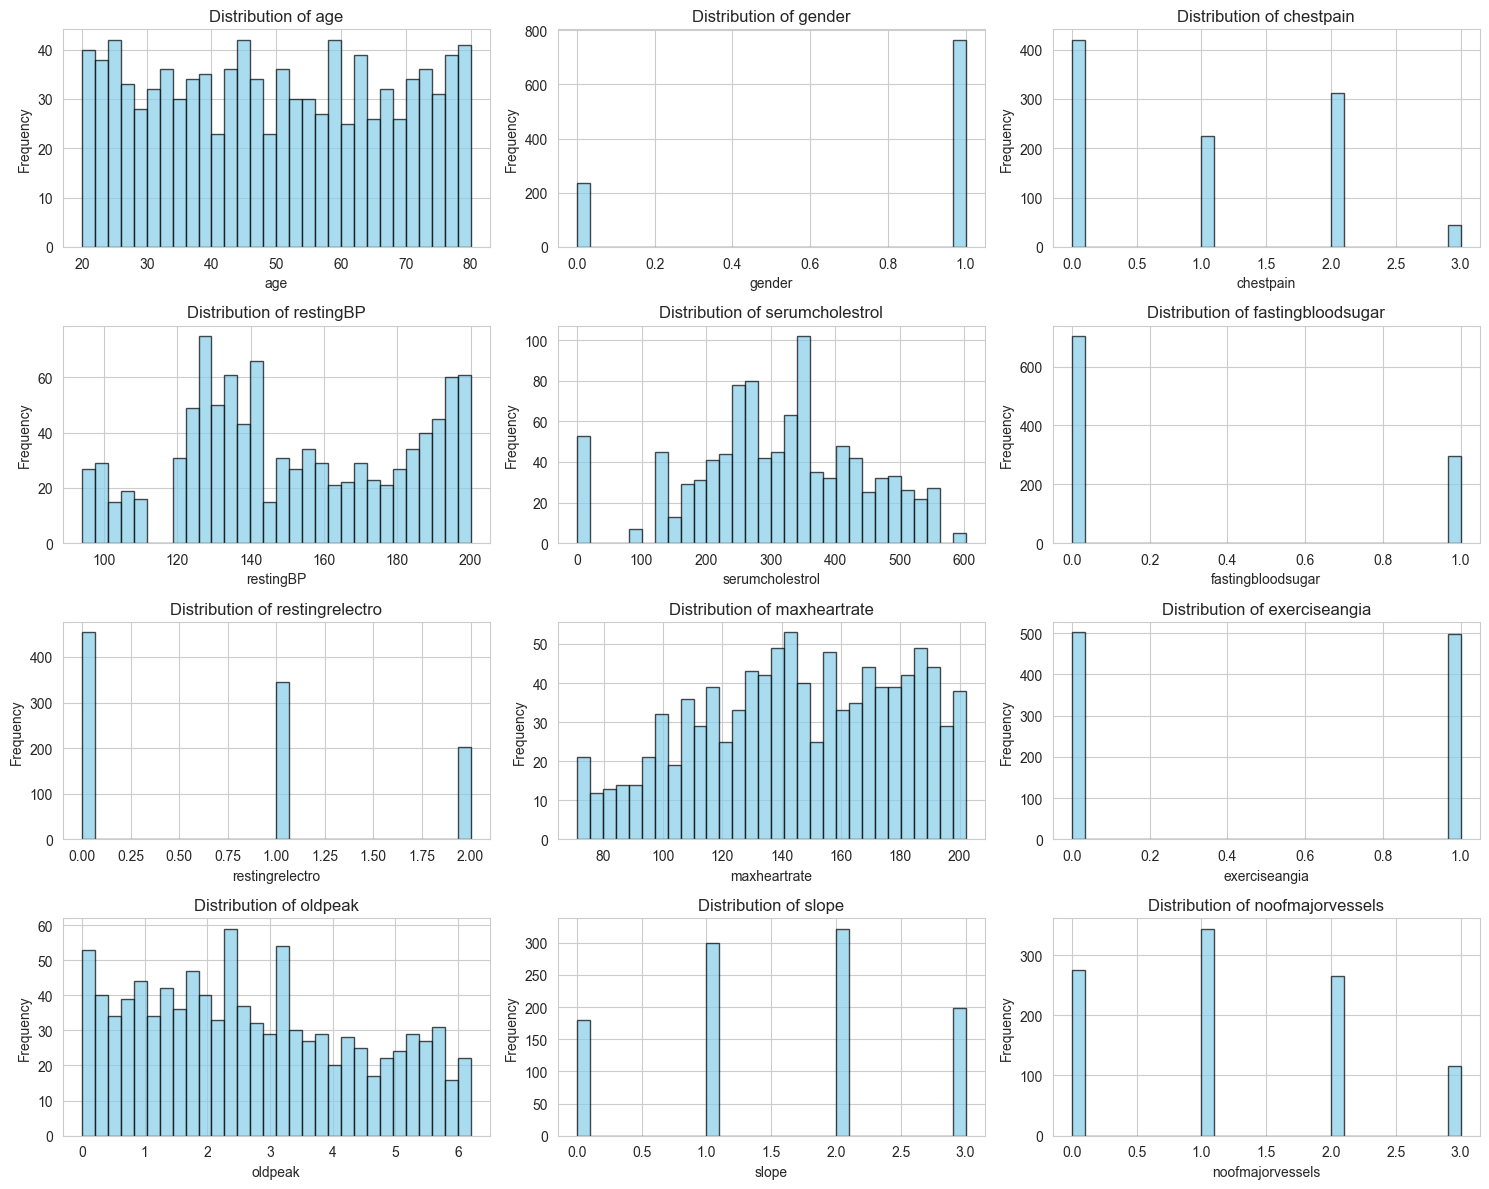


Feature distributions plotted successfully!


In [4]:
# Plot distributions of key features
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Select numerical features (excluding patientid and target)
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
if 'patientid' in numerical_features:
    numerical_features.remove('patientid')
if 'target' in numerical_features:
    numerical_features.remove('target')

print(f"\nNumerical Features: {numerical_features}")

# Plot distribution of features
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features[:12]):
    axes[idx].hist(df[feature], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nFeature distributions plotted successfully!")

## Step 3b: Correlation Analysis

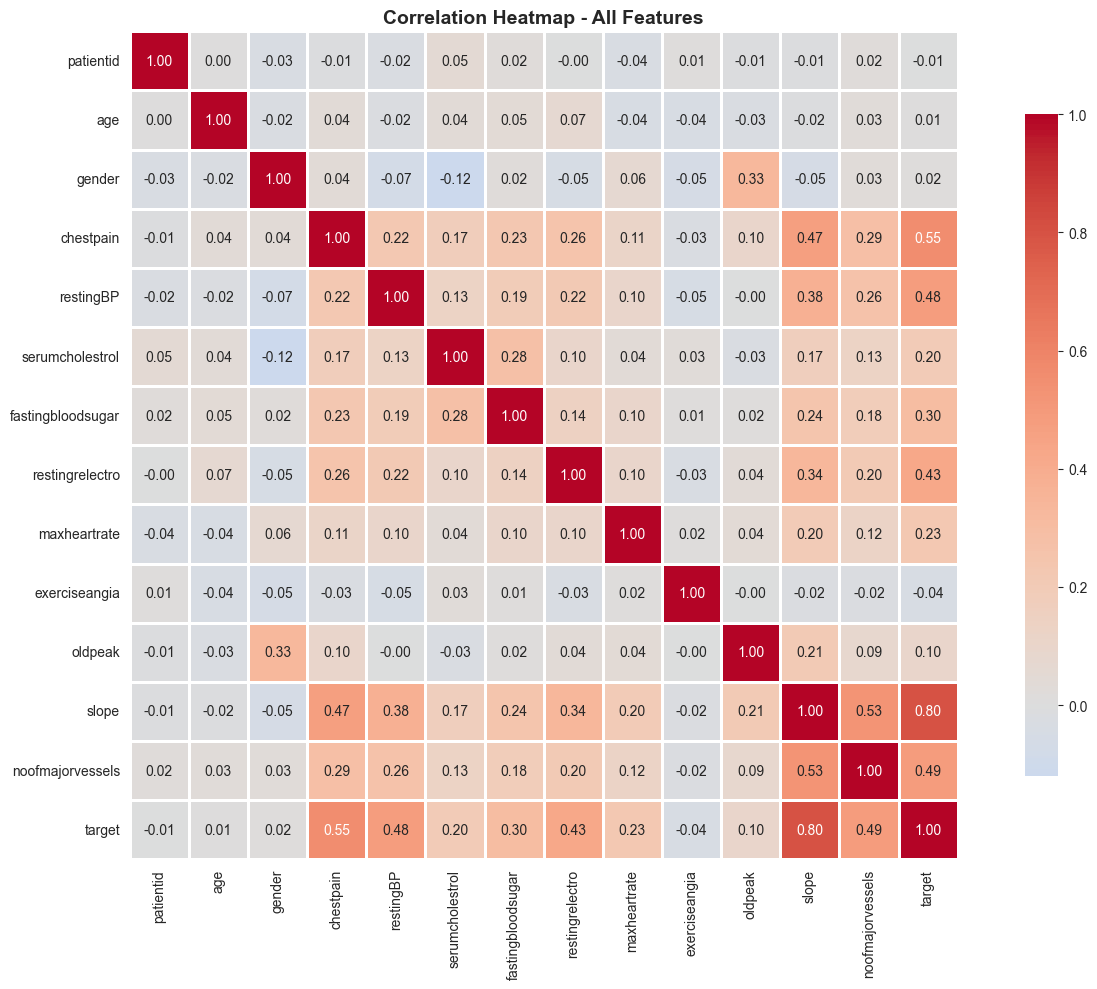


Correlation with Target Variable (sorted):
target               1.000000
slope                0.797358
chestpain            0.554228
noofmajorvessels     0.489866
restingBP            0.482387
restingrelectro      0.426837
fastingbloodsugar    0.303233
maxheartrate         0.228343
serumcholestrol      0.195340
oldpeak              0.098053
gender               0.015769
age                  0.008356
patientid           -0.005637
exerciseangia       -0.039874
Name: target, dtype: float64

Features with strong correlation to target (>0.1): ['slope', 'chestpain', 'noofmajorvessels', 'restingBP', 'restingrelectro', 'fastingbloodsugar', 'maxheartrate', 'serumcholestrol']


In [5]:
# Create correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Show correlation with target variable
print("\nCorrelation with Target Variable (sorted):")
target_corr = correlation_matrix['target'].sort_values(ascending=False)
print(target_corr)

# Identify features strongly correlated with target (abs correlation > 0.1)
strong_features = target_corr[abs(target_corr) > 0.1].index.tolist()
if 'target' in strong_features:
    strong_features.remove('target')
print(f"\nFeatures with strong correlation to target (>0.1): {strong_features}")

## Step 4: Feature Selection
Drop irrelevant columns and select important features

In [6]:
print("="*60)
print("FEATURE SELECTION")
print("="*60)

# Create a copy for feature engineering
df_processed = df.copy()

# Drop patientid as it's not a predictive feature
df_processed = df_processed.drop('patientid', axis=1)

print(f"\nOriginal features: {df_processed.shape[1] - 1} (excluding target)")
print(f"Features after removing patientid: {df_processed.shape[1] - 1} (excluding target)")

# Justification for feature selection
print("\nFeature Selection Justification:")
print("- PatientID: Removed (not a predictive feature, just identifier)")
print("- All other features: Retained (all are medically relevant for heart disease prediction)")
print(f"\nFinal features to use: {list(df_processed.drop('target', axis=1).columns)}")

FEATURE SELECTION

Original features: 12 (excluding target)
Features after removing patientid: 12 (excluding target)

Feature Selection Justification:
- PatientID: Removed (not a predictive feature, just identifier)
- All other features: Retained (all are medically relevant for heart disease prediction)

Final features to use: ['age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels']


## Step 5: Outlier Detection
Detect and handle outliers using IQR method

OUTLIER DETECTION

Number of rows with outliers: 235
Percentage of outliers: 23.50%


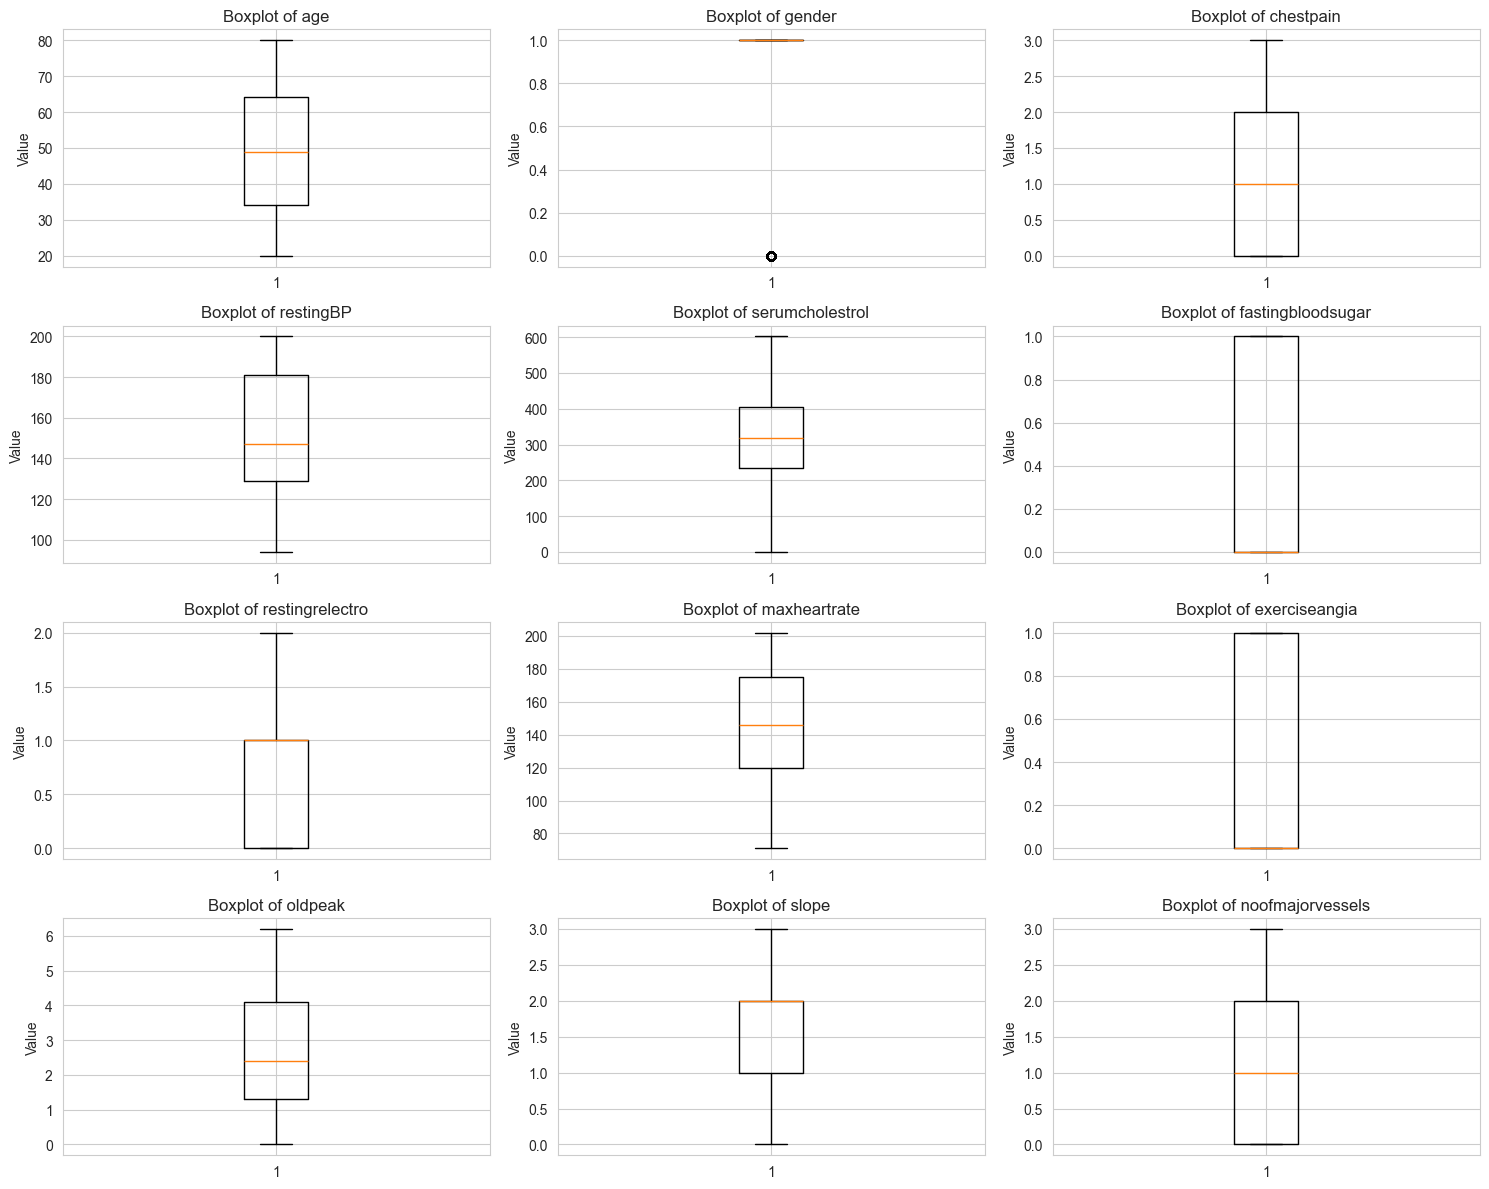


Outlier Handling Strategy: Keep outliers (they represent extreme but valid medical cases)
Dataset shape remains: (1000, 13)


In [7]:
print("="*60)
print("OUTLIER DETECTION")
print("="*60)

# Store original shape
original_rows = len(df_processed)

# Function to detect outliers using IQR method
def detect_outliers_iqr(dataframe, columns):
    outlier_indices = set()
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Find outlier indices
        col_outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)].index
        outlier_indices.update(col_outliers)
    
    return outlier_indices

# Get all numeric columns except target
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('target') if 'target' in numeric_cols else None

# Detect outliers
outlier_indices = detect_outliers_iqr(df_processed, numeric_cols)
print(f"\nNumber of rows with outliers: {len(outlier_indices)}")
print(f"Percentage of outliers: {(len(outlier_indices)/original_rows*100):.2f}%")

# Plot boxplots to visualize outliers
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols[:12]):
    axes[idx].boxplot(df_processed[col], vert=True)
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nOutlier Handling Strategy: Keep outliers (they represent extreme but valid medical cases)")
print(f"Dataset shape remains: {df_processed.shape}")

## Step 6: Data Preprocessing
Normalize/Standardize features and encode categorical variables

In [9]:
print("="*60)
print("DATA PREPROCESSING")
print("="*60)

# Separate features and target
X = df_processed.drop('target', axis=1)
y = df_processed['target']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Check for categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns: {categorical_cols if categorical_cols else 'None'}")

# If there are categorical columns, encode them
if categorical_cols:
    print("\nEncoding categorical variables...")
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    print(f"Features shape after encoding: {X.shape}")

# Standardize/Normalize numerical features using StandardScaler
print("\nStandardizing numerical features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Scaled features shape: {X_scaled.shape}")
print("\nScaled features - Sample statistics:")
print(X_scaled.describe())

# Save the scaler for later use with new data
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\nScaler saved to 'scaler.pkl'")

DATA PREPROCESSING

Features shape: (1000, 12)
Target shape: (1000,)

Categorical columns: None

Standardizing numerical features...
Scaled features shape: (1000, 12)

Scaled features - Sample statistics:
                age        gender     chestpain     restingBP  \
count  1.000000e+03  1.000000e+03  1.000000e+03  1.000000e+03   
mean   1.421085e-16 -5.329071e-17 -3.552714e-18 -4.760636e-16   
std    1.000500e+00  1.000500e+00  1.000500e+00  1.000500e+00   
min   -1.637676e+00 -1.804250e+00 -1.028677e+00 -1.928098e+00   
25%   -8.536164e-01  5.542468e-01 -1.028677e+00 -7.594930e-01   
50%   -1.355302e-02  5.542468e-01  2.099340e-02 -1.584962e-01   
75%    8.405114e-01  5.542468e-01  1.070663e+00  9.767200e-01   
max    1.722578e+00  5.542468e-01  2.120333e+00  1.611106e+00   

       serumcholestrol  fastingbloodsugar  restingrelectro  maxheartrate  \
count     1.000000e+03       1.000000e+03     1.000000e+03  1.000000e+03   
mean     -2.486900e-17       7.105427e-18     4.263256e-1

## Step 7: Train-Test Split
Split the dataset into Training (80%) and Testing (20%) sets

In [11]:
print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples (80%)")
print(f"Testing set size: {X_test.shape[0]} samples (20%)")
print(f"\nTraining set - Feature columns: {X_train.shape[1]}")
print(f"Testing set - Feature columns: {X_test.shape[1]}")

print(f"\nTraining set - Target distribution:")
print(f"  Disease cases: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.2f}%)")
print(f"  No-disease cases: {len(y_train) - y_train.sum()} ({(1-y_train.sum()/len(y_train))*100:.2f}%)")

print(f"\nTesting set - Target distribution:")
print(f"  Disease cases: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")
print(f"  No-disease cases: {len(y_test) - y_test.sum()} ({(1-y_test.sum()/len(y_test))*100:.2f}%)")

TRAIN-TEST SPLIT

Training set size: 800 samples (80%)
Testing set size: 200 samples (20%)

Training set - Feature columns: 12
Testing set - Feature columns: 12

Training set - Target distribution:
  Disease cases: 464 (58.00%)
  No-disease cases: 336 (42.00%)

Testing set - Target distribution:
  Disease cases: 116 (58.00%)
  No-disease cases: 84 (42.00%)


## Step 8: Model Training
Train Support Vector Machine (SVM) model

In [12]:
print("="*60)
print("MODEL TRAINING")
print("="*60)

# Initialize and train Support Vector Machine (SVM) model
print("\nTraining Support Vector Machine (SVM) model...")
model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
model.fit(X_train, y_train)

print("Model trained successfully!")

# Display model parameters
print(f"\nModel Parameters:")
print(f"  - Kernel: rbf")
print(f"  - C (Regularization): 1.0")
print(f"  - Gamma: scale")
print(f"  - Number of support vectors: {len(model.support_vectors_)}")
print(f"  - Number of features: {model.support_vectors_.shape[1]}")

MODEL TRAINING

Training Support Vector Machine (SVM) model...
Model trained successfully!

Model Parameters:
  - Kernel: rbf
  - C (Regularization): 1.0
  - Gamma: scale
  - Number of support vectors: 198
  - Number of features: 12


## Step 9: Model Predictions and Overfitting Check
Make predictions and compare training vs testing accuracy

In [13]:
print("="*60)
print("MODEL PREDICTIONS & OVERFITTING CHECK")
print("="*60)

# Make predictions on training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nAccuracy Scores:")
print(f"  Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Testing Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Calculate accuracy difference
accuracy_diff = train_accuracy - test_accuracy
print(f"\nAccuracy Difference (Train - Test): {accuracy_diff:.4f}")

# Overfitting Analysis
print(f"\nOVERFITTING ANALYSIS:")
if accuracy_diff > 0.05:
    print(f"  Potential OVERFITTING detected")
    print(f"   The training accuracy is significantly higher than testing accuracy.")
    print(f"   The model may have memorized training patterns.")
elif accuracy_diff < -0.05:
    print(f"  Potential UNDERFITTING detected")
    print(f"   The training accuracy is lower than testing accuracy.")
    print(f"   This is unusual but may indicate high variance in test data.")
else:
    print(f" Good model generalization")
    print(f"   Training and testing accuracies are well-balanced.")
    print(f"   The model generalizes well to unseen data.")

MODEL PREDICTIONS & OVERFITTING CHECK

Accuracy Scores:
  Training Accuracy: 0.9862 (98.62%)
  Testing Accuracy:  0.9650 (96.50%)

Accuracy Difference (Train - Test): 0.0212

OVERFITTING ANALYSIS:
 Good model generalization
   Training and testing accuracies are well-balanced.
   The model generalizes well to unseen data.


## Step 10: Model Evaluation
Detailed evaluation with accuracy, confusion matrix, and classification report

DETAILED MODEL EVALUATION

1. ACCURACY SCORE
   Test Accuracy: 0.9650 (96.50%)

2. CONFUSION MATRIX
   True Negatives (TN):  79  | False Positives (FP): 5
   False Negatives (FN): 2 | True Positives (TP):  114


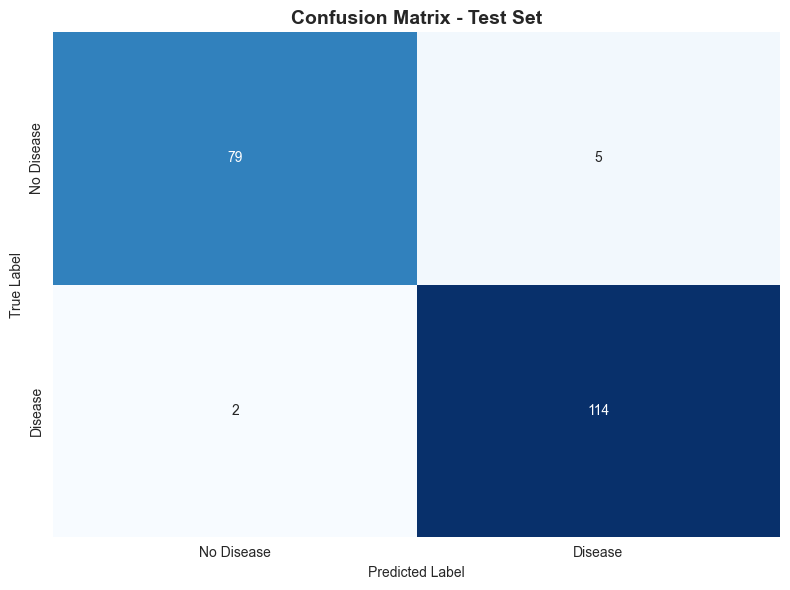


3. CLASSIFICATION REPORT
                precision    recall  f1-score   support

No Disease (0)     0.9753    0.9405    0.9576        84
   Disease (1)     0.9580    0.9828    0.9702       116

      accuracy                         0.9650       200
     macro avg     0.9666    0.9616    0.9639       200
  weighted avg     0.9653    0.9650    0.9649       200



In [14]:
print("="*60)
print("DETAILED MODEL EVALUATION")
print("="*60)

# 1. Accuracy Score
print(f"\n1. ACCURACY SCORE")
print(f"   Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\n2. CONFUSION MATRIX")
print(f"   True Negatives (TN):  {cm[0, 0]}  | False Positives (FP): {cm[0, 1]}")
print(f"   False Negatives (FN): {cm[1, 0]} | True Positives (TP):  {cm[1, 1]}")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# 3. Classification Report
print(f"\n3. CLASSIFICATION REPORT")
print(classification_report(
    y_test, y_test_pred,
    target_names=['No Disease (0)', 'Disease (1)'],
    digits=4
))

## Step 11: Model Saving
Save the trained model using pickle

In [15]:
print("="*60)
print("MODEL SAVING")
print("="*60)

# Save the trained model
model_filename = 'heart_disease_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(model, f)

print(f"\n Model saved successfully!")
print(f"  Filename: {model_filename}")
print(f"  File size: {len(pickle.dumps(model))} bytes")

# Also save the feature column names for later use
feature_names = X_scaled.columns.tolist()
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print(f"\n Feature names saved successfully!")
print(f"  Filename: feature_names.pkl")
print(f"  Number of features: {len(feature_names)}")

MODEL SAVING

 Model saved successfully!
  Filename: heart_disease_model.pkl
  File size: 24498 bytes

 Feature names saved successfully!
  Filename: feature_names.pkl
  Number of features: 12


## Step 12: Prediction on New Data
Create sample input and predict using the saved model

In [16]:
print("="*60)
print("PREDICTION ON NEW DATA")
print("="*60)

# Load the saved model
with open('heart_disease_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Load the scaler
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Load feature names
with open('feature_names.pkl', 'rb') as f:
    loaded_feature_names = pickle.load(f)

print("\nModels and scalers loaded successfully!")

# Create sample input data for a new patient
# Using mean values and some variations
print("\n" + "="*60)
print("SAMPLE PATIENT #1 - PREDICTION")
print("="*60)

sample_patient_1 = {
    'age': 55,
    'gender': 1,
    'chestpain': 1,
    'restingBP': 140,
    'serumcholestrol': 250,
    'fastingbloodsugar': 1,
    'restingrelectro': 1,
    'maxheartrate': 120,
    'exerciseangia': 1,
    'oldpeak': 2.5,
    'slope': 2,
    'noofmajorvessels': 2
}

print("\nPatient Information:")
for key, value in sample_patient_1.items():
    print(f"  {key}: {value}")

# Convert to DataFrame
sample_df_1 = pd.DataFrame([sample_patient_1])

# Scale the sample using the same scaler
sample_scaled_1 = loaded_scaler.transform(sample_df_1)
sample_scaled_1 = pd.DataFrame(sample_scaled_1, columns=loaded_feature_names)

# Make prediction
prediction_1 = loaded_model.predict(sample_scaled_1)[0]
prediction_prob_1 = loaded_model.predict_proba(sample_scaled_1)[0]

print("\n" + "-"*60)
print("PREDICTION RESULT:")
print("-"*60)
if prediction_1 == 1:
    print("✓✓✓ The patient HAS heart disease ✓✓✓")
else:
    print("✓✓✓ The patient DOES NOT have heart disease ✓✓✓")

print(f"\nPrediction Probabilities:")
print(f"  Probability of No Disease: {prediction_prob_1[0]:.4f} ({prediction_prob_1[0]*100:.2f}%)")
print(f"  Probability of Disease:    {prediction_prob_1[1]:.4f} ({prediction_prob_1[1]*100:.2f}%)")
print(f"\nConfidence Level: {max(prediction_prob_1):.4f}")

PREDICTION ON NEW DATA

Models and scalers loaded successfully!

SAMPLE PATIENT #1 - PREDICTION

Patient Information:
  age: 55
  gender: 1
  chestpain: 1
  restingBP: 140
  serumcholestrol: 250
  fastingbloodsugar: 1
  restingrelectro: 1
  maxheartrate: 120
  exerciseangia: 1
  oldpeak: 2.5
  slope: 2
  noofmajorvessels: 2

------------------------------------------------------------
PREDICTION RESULT:
------------------------------------------------------------
✓✓✓ The patient HAS heart disease ✓✓✓

Prediction Probabilities:
  Probability of No Disease: 0.0128 (1.28%)
  Probability of Disease:    0.9872 (98.72%)

Confidence Level: 0.9872


## Step 12b: Additional Sample Predictions

In [17]:
# Create second sample patient (healthier profile)
print("\n" + "="*60)
print("SAMPLE PATIENT #2 - PREDICTION")
print("="*60)

sample_patient_2 = {
    'age': 45,
    'gender': 0,
    'chestpain': 0,
    'restingBP': 120,
    'serumcholestrol': 200,
    'fastingbloodsugar': 0,
    'restingrelectro': 0,
    'maxheartrate': 160,
    'exerciseangia': 0,
    'oldpeak': 0.5,
    'slope': 1,
    'noofmajorvessels': 0
}

print("\nPatient Information:")
for key, value in sample_patient_2.items():
    print(f"  {key}: {value}")

# Convert to DataFrame and scale
sample_df_2 = pd.DataFrame([sample_patient_2])
sample_scaled_2 = loaded_scaler.transform(sample_df_2)
sample_scaled_2 = pd.DataFrame(sample_scaled_2, columns=loaded_feature_names)

# Make prediction
prediction_2 = loaded_model.predict(sample_scaled_2)[0]
prediction_prob_2 = loaded_model.predict_proba(sample_scaled_2)[0]

print("\n" + "-"*60)
print("PREDICTION RESULT:")
print("-"*60)
if prediction_2 == 1:
    print("✓✓✓ The patient HAS heart disease ✓✓✓")
else:
    print("✓✓✓ The patient DOES NOT have heart disease ✓✓✓")

print(f"\nPrediction Probabilities:")
print(f"  Probability of No Disease: {prediction_prob_2[0]:.4f} ({prediction_prob_2[0]*100:.2f}%)")
print(f"  Probability of Disease:    {prediction_prob_2[1]:.4f} ({prediction_prob_2[1]*100:.2f}%)")
print(f"\nConfidence Level: {max(prediction_prob_2):.4f}")


SAMPLE PATIENT #2 - PREDICTION

Patient Information:
  age: 45
  gender: 0
  chestpain: 0
  restingBP: 120
  serumcholestrol: 200
  fastingbloodsugar: 0
  restingrelectro: 0
  maxheartrate: 160
  exerciseangia: 0
  oldpeak: 0.5
  slope: 1
  noofmajorvessels: 0

------------------------------------------------------------
PREDICTION RESULT:
------------------------------------------------------------
✓✓✓ The patient DOES NOT have heart disease ✓✓✓

Prediction Probabilities:
  Probability of No Disease: 0.9971 (99.71%)
  Probability of Disease:    0.0029 (0.29%)

Confidence Level: 0.9971
